In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
IMAGE_SIZE = (32, 32)
VALIDATION_SIZE = 0.20

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATASET_DIR = PROJECT_ROOT / "dataset"
TRAIN_CSV = DATASET_DIR / "Train.csv"
TRAIN_DIR = DATASET_DIR / "Train"

if not TRAIN_CSV.exists():
    raise FileNotFoundError(f"Training labels were not found: {TRAIN_CSV}")
if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"Training image directory was not found: {TRAIN_DIR}")

print("Dataset directory:", DATASET_DIR.resolve())
print("Training labels:", TRAIN_CSV.resolve())
print("Fixed image size:", IMAGE_SIZE)

Dataset directory: D:\traffic-sign-recogonition\dataset
Training labels: D:\traffic-sign-recogonition\dataset\Train.csv
Fixed image size: (32, 32)


In [2]:
train_df = pd.read_csv(TRAIN_CSV)
required_columns = {"ClassId", "Path"}
missing_columns = required_columns - set(train_df.columns)
if missing_columns:
    raise ValueError(f"Train.csv is missing columns: {sorted(missing_columns)}")

train_df["ClassId"] = train_df["ClassId"].astype(int)
class_ids = sorted(train_df["ClassId"].unique().tolist())
expected_class_ids = list(range(43))

if class_ids != expected_class_ids:
    raise ValueError(f"Expected class IDs 0-42, found: {class_ids}")

train_df["ImagePath"] = train_df["Path"].map(lambda relative_path: DATASET_DIR / relative_path)
missing_images = train_df.loc[~train_df["ImagePath"].map(Path.exists)]
if not missing_images.empty:
    raise FileNotFoundError(f"Missing training images: {len(missing_images)}")

print("Training records:", len(train_df))
print("Number of classes:", len(class_ids))
print("Class IDs:", class_ids)

Training records: 39209
Number of classes: 43
Class IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]


Images per class:


,ImageCount
ClassId,
0,210
1,2220
2,2250
3,1410
4,1980
5,1860
6,420
7,1440
8,1410


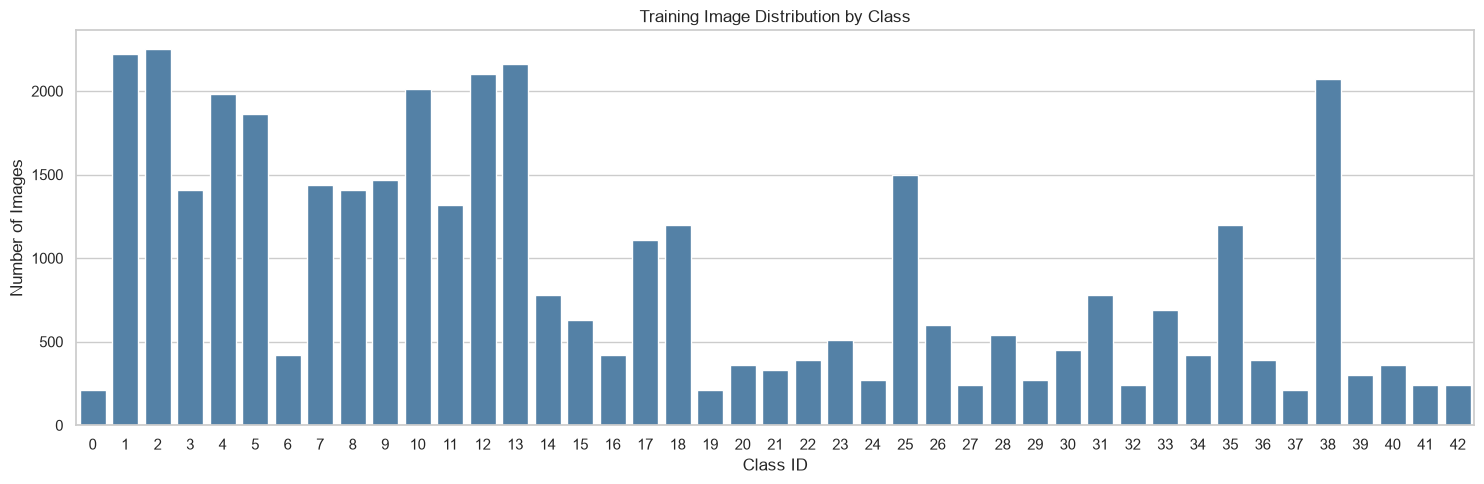

In [3]:
class_distribution = train_df["ClassId"].value_counts().sort_index()

print("Images per class:")
display(class_distribution.rename("ImageCount").to_frame())

plt.figure(figsize=(15, 5))
sns.barplot(x=class_distribution.index, y=class_distribution.values, color="steelblue")
plt.title("Training Image Distribution by Class")
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
train_indices, validation_indices = train_test_split(
    train_df.index.to_numpy(),
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=train_df["ClassId"].to_numpy(),
)

train_split_df = train_df.loc[train_indices].sort_index().reset_index(drop=True)
validation_split_df = train_df.loc[validation_indices].sort_index().reset_index(drop=True)

print("Training split records:", len(train_split_df))
print("Validation split records:", len(validation_split_df))
print("Training proportion:", len(train_split_df) / len(train_df))
print("Validation proportion:", len(validation_split_df) / len(train_df))

Training split records: 31367
Validation split records: 7842
Training proportion: 0.7999948991303018
Validation proportion: 0.20000510086969828


In [5]:
def load_images_and_labels(frame: pd.DataFrame):
    images = np.empty((len(frame), IMAGE_SIZE[1], IMAGE_SIZE[0], 3), dtype=np.float32)
    labels = frame["ClassId"].to_numpy(dtype=np.int64)

    for index, image_path in enumerate(frame["ImagePath"]):
        with Image.open(image_path) as image:
            image = image.convert("RGB")
            image = image.resize(IMAGE_SIZE, Image.Resampling.LANCZOS)
            image_array = np.asarray(image, dtype=np.float32) / 255.0

        if image_array.shape != (IMAGE_SIZE[1], IMAGE_SIZE[0], 3):
            raise ValueError(f"Unexpected image shape for {image_path}: {image_array.shape}")
        images[index] = image_array

    return images, labels

X_train, y_train = load_images_and_labels(train_split_df)
X_val, y_val = load_images_and_labels(validation_split_df)

print("Images loaded and normalized.")

Images loaded and normalized.


In [6]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_train dtype:", X_train.dtype)
print("X_val dtype:", X_val.dtype)
print("Training pixel range:", (float(X_train.min()), float(X_train.max())))
print("Validation pixel range:", (float(X_val.min()), float(X_val.max())))

assert X_train.shape[1:] == (32, 32, 3)
assert X_val.shape[1:] == (32, 32, 3)
assert y_train.shape == (len(train_split_df),)
assert y_val.shape == (len(validation_split_df),)
assert X_train.min() >= 0.0 and X_train.max() <= 1.0
assert X_val.min() >= 0.0 and X_val.max() <= 1.0

X_train shape: (31367, 32, 32, 3)
y_train shape: (31367,)
X_val shape: (7842, 32, 32, 3)
y_val shape: (7842,)
X_train dtype: float32
X_val dtype: float32
Training pixel range: (0.0, 1.0)
Validation pixel range: (0.0, 1.0)


In [7]:
train_classes_present = set(np.unique(y_train).tolist())
validation_classes_present = set(np.unique(y_val).tolist())
expected_classes = set(class_ids)

print("All 43 classes in training split:", train_classes_present == expected_classes)
print("All 43 classes in validation split:", validation_classes_present == expected_classes)
print("Missing training classes:", sorted(expected_classes - train_classes_present))
print("Missing validation classes:", sorted(expected_classes - validation_classes_present))

assert train_classes_present == expected_classes
assert validation_classes_present == expected_classes

print("\nStratified class-count check:")
class_split_counts = pd.DataFrame({
    "Training": pd.Series(y_train).value_counts().sort_index(),
    "Validation": pd.Series(y_val).value_counts().sort_index(),
})
display(class_split_counts)

All 43 classes in training split: True
All 43 classes in validation split: True
Missing training classes: []
Missing validation classes: []

Stratified class-count check:


,Training,Validation
0,168,42
1,1776,444
2,1800,450
3,1128,282
4,1584,396
5,1488,372
6,336,84
7,1152,288
8,1128,282
9,1176,294


In [8]:
print("Test data was kept separate: no test images were loaded or modified.")
print("\nSummary")
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Number of classes:", len(class_ids))
print("Image shape:", X_train.shape[1:])
print("Pixel range:", (float(X_train.min()), float(X_train.max())))
print("Random state:", RANDOM_STATE)
print("Validation split:", f"{VALIDATION_SIZE:.0%}")
print("CNN training and augmentation were not performed.")

Test data was kept separate: no test images were loaded or modified.



Summary
Training samples: 31367
Validation samples: 7842
Number of classes: 43
Image shape: (32, 32, 3)


Pixel range: (0.0, 1.0)
Random state: 42
Validation split: 20%
CNN training and augmentation were not performed.
